# Fine-tuning U-Net architecture
Modèles basés sur l'architeture U-Net :
- U-Net avec encodeur ResNet34
- ResAttentionUNetPlusPlus
- Attention Gated Multi ResU-Net

In [3]:
import numpy as np
import torch
import torch.optim as optim
import pickle 
import time
import sys
import pandas as pd

from torch.nn import functional as F
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
import segmentation_models_pytorch as smp
from pathlib import Path
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold

sys.path.append(str(Path.cwd().parent)) # Ajoute le dossier parent au chemin de recherche de Python

# Importation des classes de dataset personnalisées
from utils.dataset_unet import RoboflowUNetDataset

# Importation des fonctions utilitaires
from utils.models_config import collate_fn, split_dataset, BCE_DiceLoss, dataset_to_dict, BCE_DiceLoss_ignore
from utils.post_traitement import keep_largest_components

# Importation des modèles U-Net personnalisés
from models.ResAttentionUNetPlusPlus import ResAttentionUNetPlusPlus
from models.AttentionMultiResUNet import AttentionMultiResUNet

In [4]:
import random

# Seed global pour la reproductibilité
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Déterminisme complet des opérations cuDNN (au prix d'un léger ralentissement)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

### =========== Choix du modèle ===========

In [5]:
model_name = "UNet"  # Choix du modèle : "UNet", "AttentionUNet++", "MultiResUnet"

### =========== Choix des données ===========

In [6]:
DATASET_NAME = "oeufs"  # "classique" ou "oeufs"

### Importation et traitement des données

In [7]:
# -------- 1. Importation des données --------
DATASET_CONFIG = {
    "classique": {"images": "../data/COCO/images", "annotations": "../data/COCO/annotations.json"},
    "oeufs": {"images": "../data/COCO/oeufs", "annotations": "../data/COCO/annotations.oeufs.json"},
}
all_images_dir = DATASET_CONFIG[DATASET_NAME]["images"]
annotations_json = DATASET_CONFIG[DATASET_NAME]["annotations"]

# Importation du Data Frame avec les metadata
df = pd.read_excel("../utils/correspondance_echo_final.xlsx", dtype={"annee" : str, "image_id": str, "new_name_file": str})

# Formatage et regroupement des images et des annotations dans un dictionnaire pour faciliter l'accès aux données
# ignore_category_id : id COCO de la catégorie "Gonade_ignore" si elle existe dans l'export (None sinon).
all_samples, categories, num_classes, class_ids, ignore_category_id = dataset_to_dict(df, annotations_json, all_images_dir)

# La zone ignore ne concerne que le canal Gonade lorsqu'il existe.
gonade_channel_idx = class_ids.index(next((cid for cid, name in categories.items() if name == "Gonade"), class_ids[0])) if ignore_category_id is not None else None
class_names = [categories[cid] for cid in class_ids]
print(f"Dataset={DATASET_NAME}, classes={class_names}")

Classes détectées (1) : {1: 'Oeuf'}
Dataset=oeufs, classes=['Oeuf']


### Division du jeu de données

In [8]:
IMAGE_SIZE = (512, 512)

cv_samples, test_samples, cv_categories, test_categories, groups_train, groups_test, cv_dataset, test_dataset = split_dataset(all_samples, all_images_dir, df, IMAGE_SIZE, num_classes, 
                                                                                                                              class_ids, dim="2",
                                                                                                                              ignore_category_id=ignore_category_id,
                                                                                                                              ignore_target_class_idx=gonade_channel_idx)
print(f"Shape des images: {test_dataset[0]['image'].shape}")

Nombre total d'images valides : 68
Échantillons train/val        : 56
Échantillons de test          : 12
Shape des images: torch.Size([3, 512, 512])


### Hyperparamètres du modèle et initialisation

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de l'appareil: {device}")

# ---- Hyperparamètres ----
epochs = 150
nb_channels = 3
learning_rate = 1e-4

# ---- Fct de perte ----
# BCE_DiceLoss_ignore : identique à BCE_DiceLoss mais exclut les pixels marqués -100
# (zones "ignore") du calcul de la BCE et du Dice.
loss_fn = BCE_DiceLoss_ignore(bce_weight=0.5, dice_weight=0.5, ignore_index=-100) # Fct de perte combinée BCE + Dice Loss

# ---- Early stopping config ----
early_stopping_patience = 10  # nombre d'epochs sans amélioration avant arrêt
early_stopping_min_delta = 1e-3  # amélioration minimale considérée comme significative
lr_patience = 4

# ---- Cross validation k-folds ----
k_folds = 5
if DATASET_NAME == "oeufs":
    # Les œufs n'ont pas de catégories d'échographie : on groupe uniquement par poisson.
    kf = GroupKFold(n_splits=k_folds)
else:
    # Pour les gonades, on groupe par catégories et par poisson
    kf = StratifiedGroupKFold(n_splits=k_folds, shuffle=True, random_state=42)

def get_cv_splits():
    if DATASET_NAME == "oeufs":
        return kf.split(X, groups=groups_train)
    return kf.split(X, cv_categories, groups_train)
X = np.array(cv_samples, dtype=object) # Les images

# Initialisation
fold_results = {}
fold_histories = {}
best_epochs = []

Utilisation de l'appareil: cuda


### Images selectionnées par batch

In [9]:
# ------------------ ENTRAINEMENT + VALIDATION ------------------
for fold, (train_idx, val_idx) in enumerate(get_cv_splits()):
    print(f"--- DEBUT DU FOLD {fold + 1}/{k_folds} ---")
    val_names = [x["image_info"]["file_name"] for x in cv_samples[val_idx]]
    print(val_names)


--- DEBUT DU FOLD 1/5 ---
['0004575_10.31.12_356302_2019.jpg', '0004656_11.28.59_356877_2019.jpg', '0004732_11.19.29_357305_2019.jpg', '0004733_11.19.54_357305_2019.jpg', '0004880_15.30.04_362793_2020.jpg', '0005957_13.57.27_405924_2022.jpg', '0006147_14.56.42_406377_2022.jpg', '0006148_14.57.15_406377_2022.jpg', '0006149_14.57.29_406377_2022.jpg', '0006943_10.28.10_426735_2024.jpg', '0007130_10.24.52_427237_2024.jpg', '0007139_10.42.50_427266_2024.jpg']
--- DEBUT DU FOLD 2/5 ---
['0004650_11.22.45_356868_2019.jpg', '0004722_11.07.19_357291_2019.jpg', '0004723_11.07.34_357291_2019.jpg', '0004877_15.28.11_362791_2020.jpg', '0005926_11.36.05_405826_2022.jpg', '0006009_16.23.20_406070_2022.jpg', '0006010_16.23.49_406070_2022.jpg', '0006931_10.06.55_426711_2024.jpg', '0007120_09.59.50_427202_2024.jpg', '0007153_11.19.57_427305_2024.jpg', '0007156_11.21.04_427305_2024.jpg']
--- DEBUT DU FOLD 3/5 ---
['0004646_11.15.05_356859_2019.jpg', '0004677_12.34.01_356970_2019.jpg', '0004678_12.34.15_3

### Entrainement et validation du modèle

In [15]:
# ------------------ ENTRAINEMENT + VALIDATION ------------------
for fold, (train_idx, val_idx) in enumerate(get_cv_splits()):
    print(f"--- DEBUT DU FOLD {fold + 1}/{k_folds} ---")
    fold_start_time = time.time() # Initialisation temps d'execution du fold

    # -------- 1. Création des jeux de données pour ce fold --------
    train_samples = [cv_samples[i] for i in train_idx]
    val_samples = [cv_samples[i] for i in val_idx]

    # Les annotations œufs n'ont pas les métadonnées d'échographie.
    # On conserve l'échelle pour le jeu classique et on travaille en pixels sinon.
    use_physical_scale = DATASET_NAME != "oeufs"
    if use_physical_scale:
        echelle_val_fold = np.array([
            df.loc[df["image_id"] == s["image_info"]["file_name"].split("_")[0], "echelle"].values[0]
            for s in val_samples
        ]) / IMAGE_SIZE[1]

    # Générateur dédié au shuffle du train_loader pour que l'ordre des batchs soit identique quel que soit le modèle comparé.
    loader_g = torch.Generator()
    loader_g.manual_seed(SEED + fold)

    train_dataset = RoboflowUNetDataset(samples=train_samples, image_dir=all_images_dir, df = df, image_size=IMAGE_SIZE, 
                                        num_classes=num_classes, class_ids=class_ids, is_train = True,
                                        ignore_category_id=ignore_category_id, ignore_target_class_idx=gonade_channel_idx)
    val_dataset = RoboflowUNetDataset(samples=val_samples, image_dir=all_images_dir, df = df, image_size=IMAGE_SIZE, 
                                      num_classes=num_classes, class_ids=class_ids, is_train=False,
                                      ignore_category_id=ignore_category_id, ignore_target_class_idx=gonade_channel_idx)
    
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn, generator=loader_g)
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

    # Les métadonnées sont conservées pour le jeu classique uniquement.
    val_categories_fold = [sample['category'] for sample in val_samples] if use_physical_scale else []
    val_ops_fold = [int(sample['position']) for sample in val_samples] if use_physical_scale else []
    val_ops_ratio_fold = [float(sample['position_ratio']) for sample in val_samples] if use_physical_scale else []

    # -------- 2. Réinitialisation complète du Modèle et Optimiseur --------
    # Rend l'initialisation des poids (et le dropout éventuel) reproductible d'un run à l'autre pour un même modèle
    torch.manual_seed(SEED + fold)
    torch.cuda.manual_seed_all(SEED + fold)

    # ----- CHOIX DU MODELE -----
    if model_name == "UNet": # U-Net classique
        model = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet", in_channels=nb_channels, classes=num_classes, activation=None)

    if model_name == "AttentionUNet++": # Attention UNet ++
        model = ResAttentionUNetPlusPlus(num_classes=num_classes,in_channels=nb_channels,encoder_weights="imagenet")

    if model_name == "MultiResUnet": # Attention MultiResUNet
        model = AttentionMultiResUNet(in_ch=nb_channels, num_classes=num_classes)

    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4) # Optimiseur AdamW and une regularisation L2 (weight decay) pour éviter l'overfitting
    # Scheduler pour réduire le learning rate si la validation loss ne s'améliore pas
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=lr_patience)

    # -------- 2. Initialisation par fold --------
    # Dictionnaires pour sauvegarder les résultats
    history = {'train_loss': [], 
               'val_loss': [], 
               'val_iou': [],
               'val_iou_all' : [],
               'val_surf_diff': [],
               'best_epochs': []
               }
    
    best_epochs = {'iou_by_class': {},
                   'iou_all' : [],
                   'category': val_categories_fold,
                   'ops': val_ops_fold,
                   'ops_ratio': val_ops_ratio_fold,
                   'diff_surf': {},
                   'name': []
                   }
    
    best_val_loss = float('inf')
    idx_best_epoch = -1
    early_stopping_counter = 0

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()

        # Epoch courante : utilisée par le dataset pour dériver un seed d'augmentation déterministe et identique entre modèles comparés.
        train_dataset.epoch = epoch
        val_dataset.epoch = epoch
        
        # -------------- 3. Training --------------
        model.train()
        running_loss = 0.0
        running_count = 0
        for batch in train_loader:
            images = batch['image'].to(device, non_blocking=True)
            masks = batch['mask'].to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            outputs = model(images) # Outputs à trois canaux (1 par classe)
            loss = loss_fn(outputs, masks)
            loss.backward()
            optimizer.step()

            # Perte cumulée
            batch_size = images.size(0)
            running_loss += loss.item() * batch_size
            running_count += batch_size

        # Calcul de la perte moyenne de l'epoch
        avg_train_loss = running_loss / running_count if running_count > 0 else 0.0

        # -------------- 4. Validation ----------------
        model.eval()
        val_loss = 0.0
        val_count = 0.0

        epoch_intersection_all = torch.tensor(0.0, device=device)
        epoch_union_all = torch.tensor(0.0, device=device)
        epoch_intersection_by_class = torch.zeros(num_classes, device=device)
        epoch_union_by_class = torch.zeros(num_classes, device=device)
        total_diff_surface = torch.zeros(num_classes, device=device)

        epoch_all_iou_tensors = []
        epoch_iou_by_class_tensors = []
        epoch_diff_surf_tensors = []
        epoch_categories = []
        epoch_ops = []
        epoch_ops_ratio = []

        val_sample_offset = 0

        with torch.no_grad():
            for batch in val_loader:
                images = batch['image'].to(device, non_blocking=True)
                masks = batch['mask'].to(device, non_blocking=True)

                outputs = model(images)
                loss = loss_fn(outputs, masks)

                # Cumul de la perte et du nombre d'échantillons
                batch_size = images.size(0)
                val_loss += loss.item() * batch_size
                val_count += batch_size

                # Échelle facultative : les œufs sont évalués en pixels.
                if use_physical_scale:
                    echelle_batch = torch.tensor(
                        echelle_val_fold[val_sample_offset:val_sample_offset + batch_size],
                        device=device, dtype=torch.float32
                    ).view(-1, 1)
                val_sample_offset += batch_size

                # --- Prédictions ---
                # valid_mask exclut les pixels marqués -100 (zones "ignore") : ni le vrai
                # masque ni la prédiction n'y contribuent, donc ils sont exclus de l'IoU/surface
                # exactement comme s'ils n'existaient pas (au lieu d'être comptés comme "pas de gonade").
                valid_mask = masks != -100
                probs = torch.sigmoid(outputs)
                true = (masks > 0.5) & valid_mask
                preds = (probs > 0.5) & valid_mask

                # --- Post-processing : garder uniquement la plus grande composante ---
                if DATASET_NAME == "classique":
                    preds = keep_largest_components(preds) & valid_mask

                # --- Calcul de l'IoU ---
                intersection = (preds & true).float().sum((2, 3))
                union = (preds | true).float().sum((2, 3))   
                
                iou_per_img = intersection / (union + 1e-6)  
                iou_per_img[union==0] = 1.0
                epoch_iou_by_class_tensors.append(iou_per_img)

                epoch_all_iou_tensors.append(iou_per_img)
                
                # Cumul pour l'IoU Global de l'epoch
                epoch_intersection_by_class += intersection.sum(dim=0)
                epoch_union_by_class += union.sum(dim=0)
                epoch_intersection_all += intersection.sum()
                epoch_union_all += union.sum()
                
                #--- Calcul des surfaces en cm2 ---
                pred_surf_pixels = preds.float().sum((2, 3))
                true_surf_pixels = true.float().sum((2, 3))
                diff_surf_pixels = (true_surf_pixels - pred_surf_pixels).abs()
                diff_surface = diff_surf_pixels * (echelle_batch ** 2) if use_physical_scale else diff_surf_pixels
                epoch_diff_surf_tensors.append(diff_surface)
                total_diff_surface += diff_surface.sum(dim=0)

        # Transfer sur le CPU en fin d'epoch
        epoch_iou_by_class = torch.cat(epoch_iou_by_class_tensors).cpu().tolist()
        epoch_all_iou = torch.cat(epoch_all_iou_tensors).cpu().tolist()
        epoch_diff_surface = torch.cat(epoch_diff_surf_tensors).cpu().tolist()

        # Fin de la validation de l'epoch
        avg_val_loss = val_loss / val_count
        mean_val_iou = (epoch_intersection_by_class / (epoch_union_by_class + 1e-6)).mean().item()
        mean_val_iou_all = (epoch_intersection_all / (epoch_union_all + 1e-6)).item()
        mean_diff_surface = (total_diff_surface / val_count).cpu().tolist()

        scheduler.step(avg_val_loss) # Scheduler

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_iou'].append(mean_val_iou)
        history['val_iou_all'].append(mean_val_iou_all)
        history['val_surf_diff'].append(mean_diff_surface)
        
        # Early stopping + sauvegarde
        if avg_val_loss + early_stopping_min_delta < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), f"unet_finetuned_fold_{fold+1}_{model_name}.pth")
            early_stopping_counter = 0  # reset counter
            idx_best_epoch = epoch

            best_epochs['iou_all'] = epoch_all_iou
            best_epochs['iou_by_class'] = {name: [row[idx] for row in epoch_iou_by_class] for idx, name in enumerate(class_names)}
            best_epochs['diff_surf'] = {name: [row[idx] for row in epoch_diff_surface] for idx, name in enumerate(class_names)}
            best_epochs['name'] = [sample['image_info']['file_name'] for sample in val_samples]
            history['best_epochs'] = [idx_best_epoch]

        else:
            early_stopping_counter += 1

        epoch_time = time.time() - epoch_start
        print(f"Epoch {epoch}/{epochs} — train_loss: {avg_train_loss:.4f}, val_loss: {avg_val_loss:.4f}, val_iou: {mean_val_iou_all:.4f}, time: {epoch_time:.1f}s, lr : {optimizer.param_groups[0]['lr']:.2e}, early_stopping: {early_stopping_counter}/{early_stopping_patience}")

        if early_stopping_counter >= early_stopping_patience:
            print(f"EarlyStopping: arrêt après {early_stopping_counter} epochs sans amélioration (patience={early_stopping_patience}).")
            break
        
    # Résultats finaux
    print(f"Meilleur epoch (selon val_loss): {idx_best_epoch} avec val_loss={best_val_loss:.4f}")
    print(f"Modèle sauvegardé sous unet_finetuned_{fold+1}_{model_name}.pth (dernier best)")
    
    # Sauvegarde du temps d'execution
    fold_total_time = time.time() - fold_start_time
    history['fold_time_seconds'] = fold_total_time
    
    fold_results[f'fold_{fold+1}'] = best_epochs
    fold_histories[f'fold_{fold+1}'] = history

--- DEBUT DU FOLD 1/5 ---
Epoch 1/150 — train_loss: 0.9501, val_loss: 1.0873, val_iou: 0.0093, time: 2.4s, lr : 1.00e-04, early_stopping: 0/10
Epoch 2/150 — train_loss: 0.8656, val_loss: 1.0007, val_iou: 0.0113, time: 2.4s, lr : 1.00e-04, early_stopping: 0/10
Epoch 3/150 — train_loss: 0.8372, val_loss: 0.8338, val_iou: 0.0200, time: 2.4s, lr : 1.00e-04, early_stopping: 0/10
Epoch 4/150 — train_loss: 0.7878, val_loss: 0.7623, val_iou: 0.0329, time: 2.4s, lr : 1.00e-04, early_stopping: 0/10
Epoch 5/150 — train_loss: 0.7658, val_loss: 0.7404, val_iou: 0.0437, time: 2.4s, lr : 1.00e-04, early_stopping: 0/10
Epoch 6/150 — train_loss: 0.7462, val_loss: 0.7281, val_iou: 0.0539, time: 2.4s, lr : 1.00e-04, early_stopping: 0/10
Epoch 7/150 — train_loss: 0.7283, val_loss: 0.7190, val_iou: 0.0596, time: 2.3s, lr : 1.00e-04, early_stopping: 0/10
Epoch 8/150 — train_loss: 0.7142, val_loss: 0.7083, val_iou: 0.0645, time: 2.4s, lr : 1.00e-04, early_stopping: 0/10
Epoch 9/150 — train_loss: 0.7069, val_

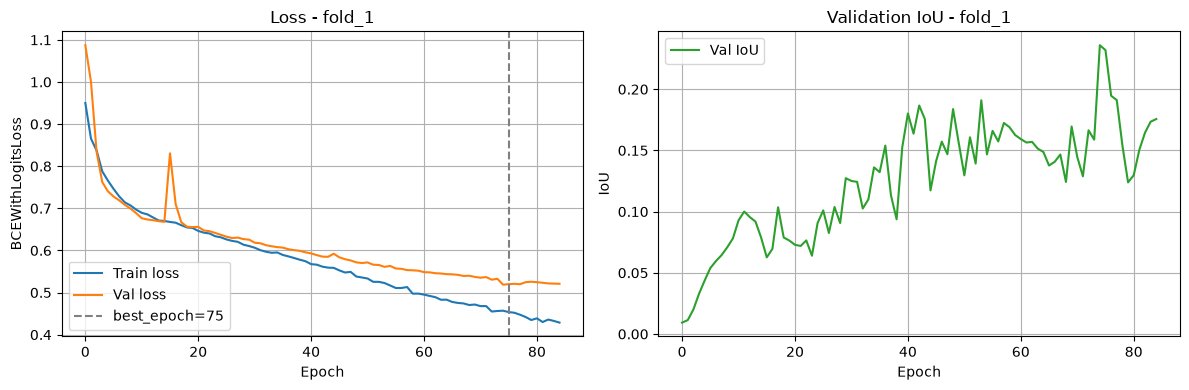

=== FOLD_1 ===
Train loss per epoch: [0.9501485228538513, 0.8656014420769431, 0.8372133320028131, 0.7877830754626881, 0.7658379728143866, 0.7462179335680875, 0.7283418828790839, 0.7141642516309564, 0.7068909027359702, 0.6969513405453075, 0.6892965002493425, 0.685656260360371, 0.6783560080961748, 0.6710759076205167, 0.6699560176242482, 0.6676734577525746, 0.6658849174326117, 0.659948771650141, 0.6547089598395608, 0.6533183238723062, 0.6464335159821943, 0.6422474438493903, 0.6403065432201732, 0.6338097615675493, 0.631173621524464, 0.626185189593922, 0.6226510080424222, 0.6205450350588019, 0.6137174584648826, 0.6104926466941833, 0.6065262989564375, 0.6007036133245989, 0.5969953699545427, 0.5944778702475808, 0.5952231558886442, 0.5892389254136519, 0.585802056572654, 0.5820006240497936, 0.5779961022463712, 0.5744192925366488, 0.5674631758169695, 0.5662583166902716, 0.5615156672217629, 0.5591918717731129, 0.5586614500392567, 0.5526541254737161, 0.5476284460587935, 0.5491219650615345, 0.53811

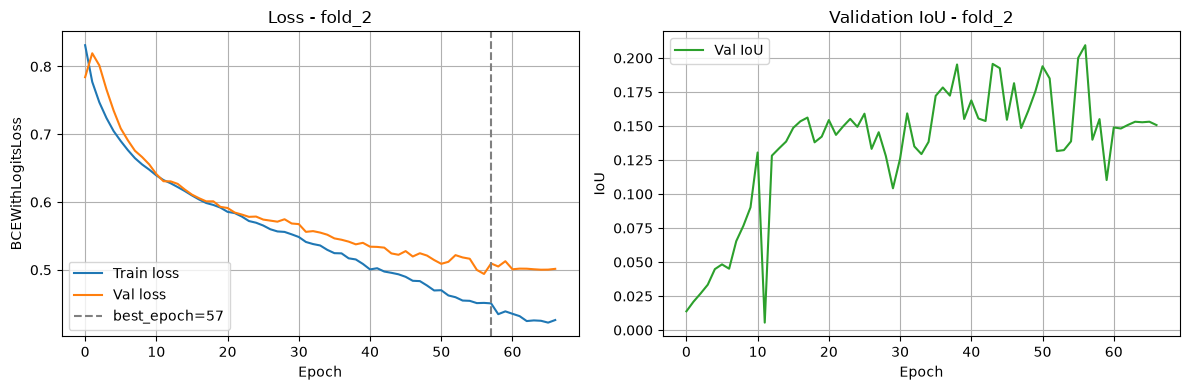

=== FOLD_2 ===
Train loss per epoch: [0.8313135782877604, 0.7772446605894301, 0.7469739370875889, 0.7238633036613464, 0.7046850045522054, 0.6899630440606012, 0.676607690917121, 0.6646681163046095, 0.6554624345567491, 0.6477882146835328, 0.6392661545011732, 0.6324198948012458, 0.6277373274167378, 0.6220713747872246, 0.6161935673819647, 0.6097279985745748, 0.6037752866744995, 0.5986041400167678, 0.5957213097148472, 0.5917555146747165, 0.585546961095598, 0.5837244232495625, 0.5786442889107598, 0.5719915800624423, 0.5695028901100159, 0.5653977606031629, 0.559887150923411, 0.5566688047515022, 0.5559478852483961, 0.5523684475156996, 0.5484667248196072, 0.541124353143904, 0.5380553285280864, 0.5359676241874695, 0.5294895145628188, 0.5246155129538642, 0.524326150947147, 0.517006864812639, 0.5153403639793396, 0.5087308684984843, 0.5006435990333558, 0.5023893435796102, 0.49750468995836045, 0.4956408315234714, 0.493425495756997, 0.48971172703637017, 0.4838658697075314, 0.48339989913834464, 0.4769

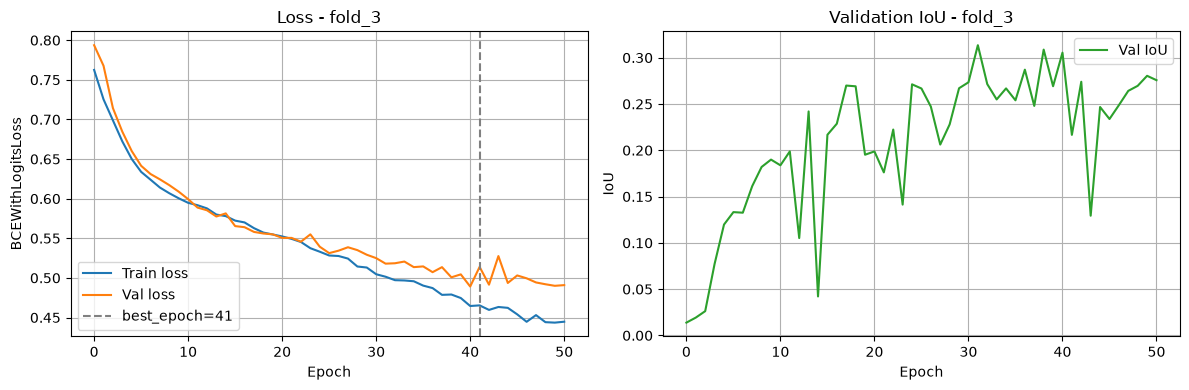

=== FOLD_3 ===
Train loss per epoch: [0.7624875730938382, 0.7253570662604438, 0.6988261183102925, 0.672280408276452, 0.6500731428464254, 0.6338482883241442, 0.6239777167638143, 0.6140226787990994, 0.6068380885654026, 0.6004593345854018, 0.5947639836205376, 0.591748403178321, 0.587746164533827, 0.5799486822552151, 0.5779875861273871, 0.5723119695981344, 0.5700262824694315, 0.5628214187092251, 0.5572309984101189, 0.5548257377412584, 0.5523375868797302, 0.5492794831593831, 0.5453169014718797, 0.5374964329931471, 0.533052921295166, 0.5282905340194702, 0.5276502701971266, 0.5243860946761237, 0.5143883321020338, 0.5131064746114943, 0.5046398056877984, 0.5014897412723965, 0.49713347620434234, 0.4967789438035753, 0.49576956695980495, 0.490283825662401, 0.48716094758775497, 0.478612658712599, 0.47904755539364285, 0.474603976143731, 0.4645436445871989, 0.46532734433809914, 0.45962166521284314, 0.46330288383695817, 0.46221168438593546, 0.4540112694104513, 0.4446259333027734, 0.4530514935652415, 0

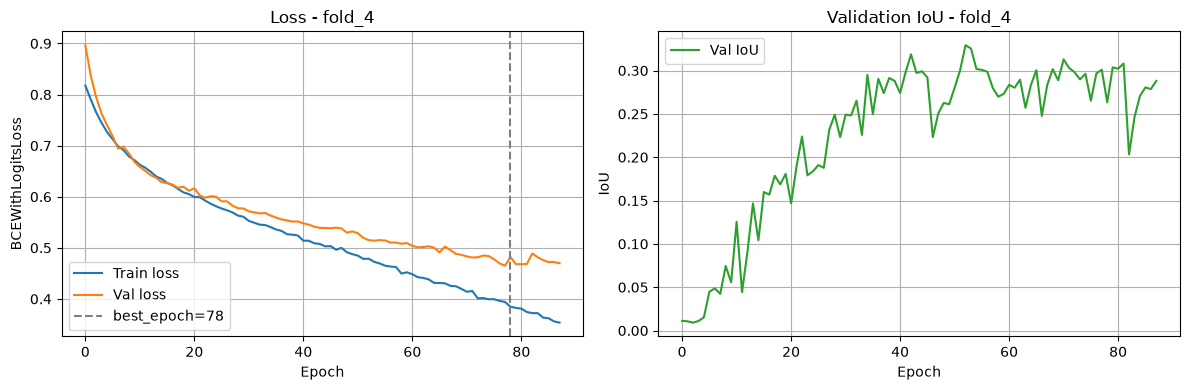

=== FOLD_4 ===
Train loss per epoch: [0.8177194092008803, 0.7902264780468411, 0.7650071488486396, 0.7444523572921753, 0.7263595859209696, 0.7128127362993029, 0.6988967061042786, 0.691246567832099, 0.6789877229266696, 0.6718591186735365, 0.6625710871484545, 0.6567955401208666, 0.6488991300264995, 0.6397586252954272, 0.6349410586886935, 0.627199673652649, 0.6225501365131803, 0.6153974519835578, 0.6086097690794203, 0.605161378118727, 0.5994775454203288, 0.5990662693977356, 0.5924104584587945, 0.5863791823387146, 0.5813338332706027, 0.5769532521565756, 0.5735055539343092, 0.5692992726961772, 0.563146154085795, 0.5609179920620389, 0.5527344160609775, 0.5490332378281487, 0.5454203340742323, 0.544590237405565, 0.5405527101622687, 0.5358884599473741, 0.5331792791684469, 0.5267581118477715, 0.525746652815077, 0.524166833029853, 0.5139847927623324, 0.5139613588651021, 0.5088938077290853, 0.5077562106980218, 0.5029633680979411, 0.50341125064426, 0.49635714292526245, 0.49986044300927057, 0.4914108

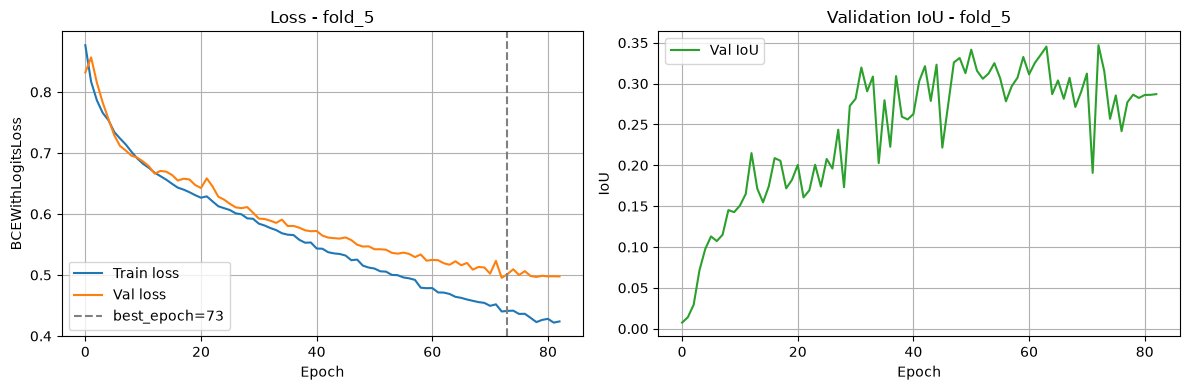

=== FOLD_5 ===
Train loss per epoch: [0.8766732162899441, 0.8168443520863851, 0.7862574815750122, 0.7658617642190721, 0.7536994563208685, 0.7344582902060615, 0.7237788730197483, 0.7139063013924493, 0.7017737732993232, 0.6908462021085952, 0.6821377992630004, 0.6755327370431689, 0.6676289876302083, 0.6619722525278727, 0.6562264813317193, 0.6494687451256647, 0.6431645525826348, 0.6399524317847358, 0.6357496023178101, 0.630862647957272, 0.6267251676983303, 0.628888808356391, 0.6206937392552694, 0.6126678638988071, 0.6095193372832404, 0.6064927697181701, 0.601072817378574, 0.5995253033108181, 0.592828795644972, 0.5921514418390063, 0.5841975688934327, 0.5810978439119127, 0.5769720117251078, 0.5736078937848409, 0.5684482892354329, 0.5660925759209527, 0.5654552472962273, 0.5576979690127902, 0.5529324995146857, 0.553325457043118, 0.543417731920878, 0.5430635611216227, 0.5373352673318651, 0.5354352209303114, 0.534428702460395, 0.5319184435738458, 0.5242454104953342, 0.5253060340881348, 0.5153563

In [19]:
import matplotlib.pyplot as plt

# Boucle sur les 5 folds de fold_histories
for i, (fold_name, history) in enumerate(fold_histories.items()):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    
    # Récupération de la meilleure époque pour le fold courant (si disponible)
    current_best_epoch = history['best_epochs'][0] if 'best_epochs' in history and history['best_epochs'] else 0

    # 1. Loss plot (train vs val)
    axs[0].plot(history['train_loss'], label='Train loss')
    axs[0].plot(history['val_loss'], label='Val loss')
    if current_best_epoch > 0:
        axs[0].axvline(current_best_epoch, color='gray', linestyle='--', label=f'best_epoch={current_best_epoch}')
    axs[0].set_title(f'Loss - {fold_name}')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('BCEWithLogitsLoss')
    axs[0].legend()
    axs[0].grid(True)

    # 2. Val IoU plot
    iou_key = 'val_iou_all' if 'val_iou_all' in history else 'val_iou'
    axs[1].plot(history[iou_key], label='Val IoU', color='tab:green')
    axs[1].set_title(f'Validation IoU - {fold_name}')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('IoU')
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

    # Afichage des logs pour le fold courant
    print(f"=== {fold_name.upper()} ===")
    print('Train loss per epoch:', history['train_loss'])
    print('Val loss per epoch:  ', history['val_loss'])
    print('Val IoU per epoch:   ', history[iou_key])
    print('=' * 50 + '\n')

### Sauvegarde des résultats

In [17]:
file_path = 'results_unet_resnet34_eggs.pkl'

In [18]:
# Sauvegarde de l'historique complet de tous les folds
with open(file_path, 'wb') as f:
    pickle.dump(fold_results, f)

### Visualisation validation

Cette section affiche une image de validation, son masque réel et la prédiction du meilleur modèle du fold sélectionné.

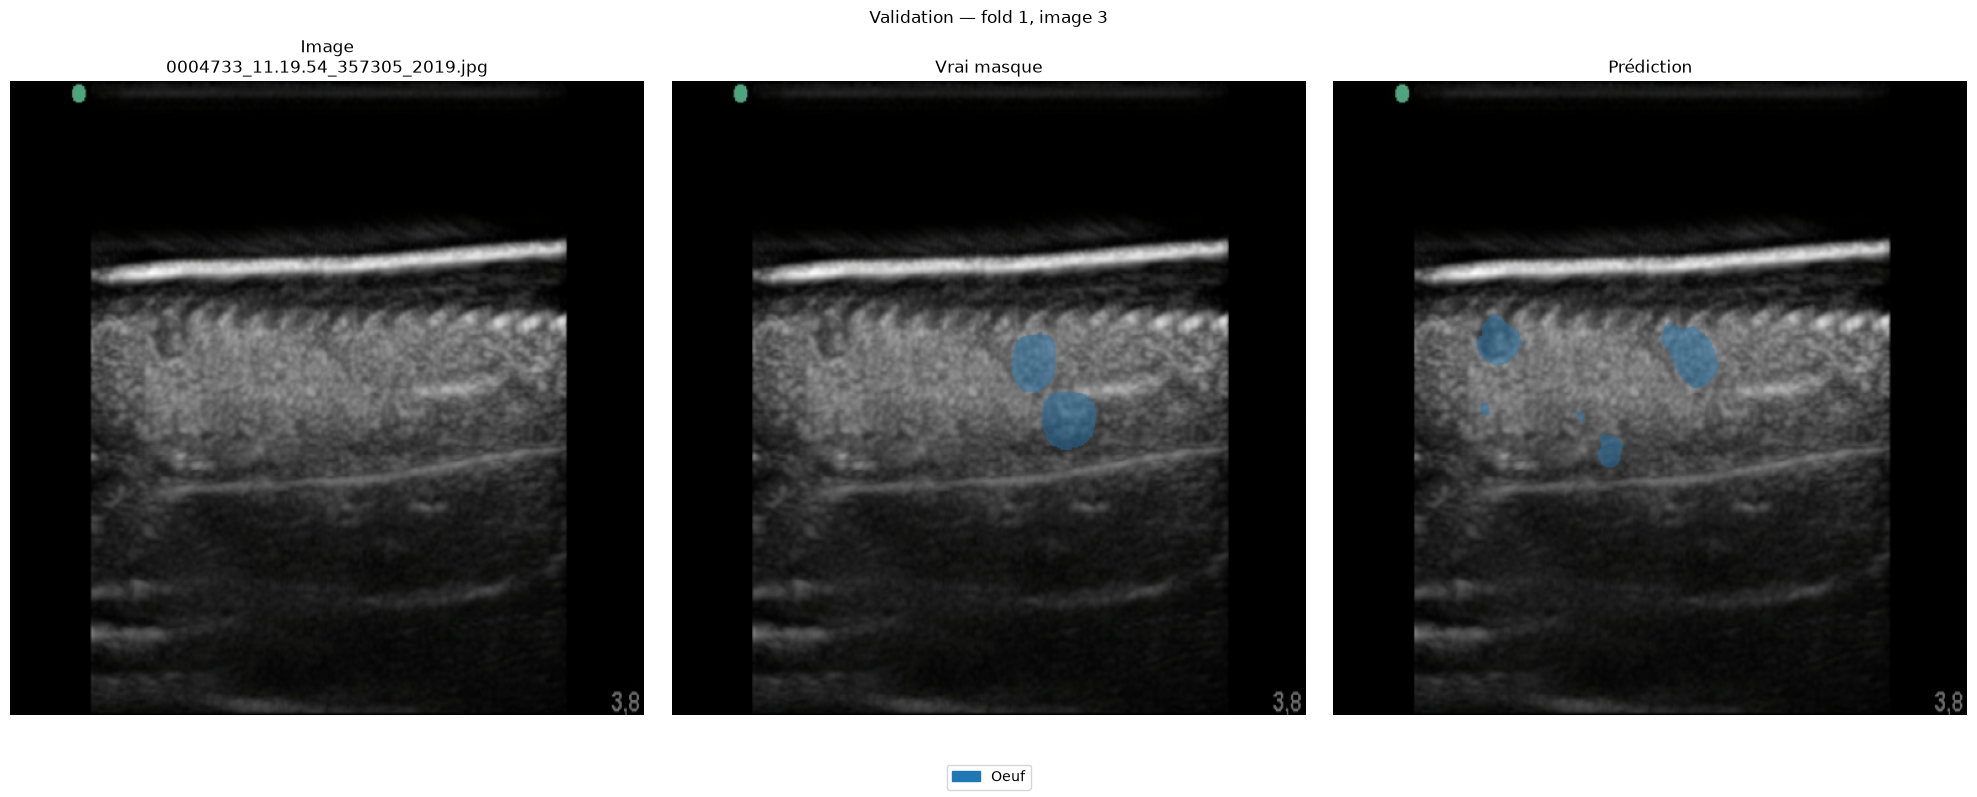

In [14]:
# -------- Sélection de l'image à visualiser --------
VIS_FOLD = 1   # Numéro du fold, entre 1 et k_folds
VIS_INDEX = 3  # Index de l'image dans le jeu de validation du fold

from matplotlib.colors import BoundaryNorm, ListedColormap

if not 1 <= VIS_FOLD <= k_folds:
    raise ValueError(f"VIS_FOLD doit être compris entre 1 et {k_folds}.")

cv_splits = list(get_cv_splits())
_, validation_indices = cv_splits[VIS_FOLD - 1]
val_samples_vis = [cv_samples[i] for i in validation_indices]

if not 0 <= VIS_INDEX < len(val_samples_vis):
    raise IndexError(
        f"VIS_INDEX doit être compris entre 0 et {len(val_samples_vis) - 1} "
        f"pour le fold {VIS_FOLD}."
    )

val_dataset_vis = RoboflowUNetDataset(
    samples=val_samples_vis, image_dir=all_images_dir, df=df,
    image_size=IMAGE_SIZE, num_classes=num_classes, class_ids=class_ids,
    is_train=False, ignore_category_id=ignore_category_id,
    ignore_target_class_idx=gonade_channel_idx,
)

if model_name == "UNet":
    model_vis = smp.Unet(encoder_name="resnet34", encoder_weights=None,
                        in_channels=nb_channels, classes=num_classes, activation=None)
elif model_name == "AttentionUNet++":
    model_vis = ResAttentionUNetPlusPlus(num_classes=num_classes, in_channels=nb_channels, encoder_weights=None)
elif model_name == "MultiResUnet":
    model_vis = AttentionMultiResUNet(in_ch=nb_channels, num_classes=num_classes)
else:
    raise ValueError(f"Modèle inconnu : {model_name}")

checkpoint_path = Path(f"unet_finetuned_fold_{VIS_FOLD}_{model_name}_eggs.pth")
if not checkpoint_path.exists():
    raise FileNotFoundError(f"Checkpoint introuvable : {checkpoint_path}")
model_vis.load_state_dict(torch.load(checkpoint_path, map_location=device))
model_vis.to(device).eval()

sample_vis = val_dataset_vis[VIS_INDEX]
image_vis, mask_vis = sample_vis['image'], sample_vis['mask']
with torch.no_grad():
    logits_vis = model_vis(image_vis.unsqueeze(0).to(device))
    preds_vis = torch.sigmoid(logits_vis) > 0.5

valid_vis = mask_vis != -100
true_vis = (mask_vis > 0.5) & valid_vis
valid_vis_batch = valid_vis.unsqueeze(0).to(device)
preds_vis = preds_vis & valid_vis_batch
if DATASET_NAME == "classique":
    preds_vis = keep_largest_components(preds_vis) & valid_vis_batch
preds_vis = preds_vis.squeeze(0).cpu()

true_label_vis = torch.zeros(mask_vis.shape[1:], dtype=torch.long)
pred_label_vis = torch.zeros(mask_vis.shape[1:], dtype=torch.long)
for class_idx in range(num_classes):
    true_label_vis[true_vis[class_idx]] = class_idx + 1
    pred_label_vis[preds_vis[class_idx]] = class_idx + 1

class_colors = ['black'] + [plt.cm.tab10(i % 10) for i in range(num_classes)]
segmentation_cmap = ListedColormap(class_colors)
segmentation_norm = BoundaryNorm(np.arange(-0.5, num_classes + 1.5), num_classes + 1)
image_display = image_vis.permute(1, 2, 0).cpu().numpy().clip(0, 1)
# Le fond (classe 0) est masqué pour laisser l'image visible sous l'overlay.
true_overlay_vis = np.ma.masked_where(true_label_vis.numpy() == 0, true_label_vis.numpy())
pred_overlay_vis = np.ma.masked_where(pred_label_vis.numpy() == 0, pred_label_vis.numpy())
file_name_vis = val_samples_vis[VIS_INDEX]['image_info']['file_name']
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
axes[0].imshow(image_display)
axes[0].set_title(f"Image\n{file_name_vis}")
axes[1].imshow(image_display)
axes[1].imshow(true_overlay_vis, cmap=segmentation_cmap, norm=segmentation_norm, alpha=0.45)
axes[1].set_title("Vrai masque")
axes[2].imshow(image_display)
axes[2].imshow(pred_overlay_vis, cmap=segmentation_cmap, norm=segmentation_norm, alpha=0.45)
axes[2].set_title("Prédiction")
for ax in axes:
    ax.axis('off')
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=class_colors[i + 1]) for i in range(num_classes)]
fig.legend(legend_handles, class_names, loc='lower center', ncol=max(1, num_classes))
fig.suptitle(f"Validation — fold {VIS_FOLD}, image {VIS_INDEX}", y=0.98)
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()